Nota: es posible que dependiendo del contaminante los mejores métodos de imputación cambien (comprobar)

In [17]:
import pandas as pd
from utils import load_dataset_paths, load_to_df, get_longest_segment

In [3]:
file_paths = load_dataset_paths("../Datos-post-COUTA/*/", key_word="NO2", file_extension="csv")

proc_ds = list() 

for path in file_paths:
    proc_ds.append(load_to_df(path))

In [4]:
longest_segment = get_longest_segment(proc_ds, False)

--- Winning Segment ---
Dimensions: 215 rows x 7 columns
Recovered columns: ['Aquatec - Pintor Balaca', 'AQN2 - San Francisco', 'Aquatec - Carlos III', 'Aquatec - Calle Real', 'Aquatec - San Diego', 'Aquatec - Ramon y Cajal', 'AQN1 - Puerto']
Range: 2024-03-19 15:00:00 to 2024-03-28 13:00:00
Score (Total area): 27.544456535888802
------------------------


In [5]:
df_common_cols = pd.concat(proc_ds, axis=1, join='outer').asfreq('h').sort_index()[longest_segment.columns]

# Buscamos el primer momento donde no hay ningún NaN
df_drop = df_common_cols.dropna(how='any')
primer_indice_valido = df_drop.index[0]
ultimo_indice_valido = df_drop.index[-1]

# Recortamos el DataFrame desde ese punto en adelante
df_final = df_common_cols.loc[primer_indice_valido:ultimo_indice_valido]

In [6]:
df_common_cols = pd.concat(proc_ds, axis=1, join='outer').asfreq('h').sort_index()

In [ ]:
from darts import TimeSeries
from darts.models import TiDEModel
from darts.dataprocessing.transformers import Scaler
from darts.utils.missing_values import extract_subseries
from torch.nn import HuberLoss
from pytorch_lightning.callbacks import ModelCheckpoint
from sklearn.preprocessing import MaxAbsScaler
import logging
import warnings

import numpy as np

from darts.metrics import rmse, mae, smape

def prepare_series(df_full, with_gaps, val_size=10):
    """
    Escalado común para todos los métodos.
    Devuelve:
        - series_scaled
        - dict_scalers
    """
    col_names = df_full.columns
    df_con_gaps = df_full.copy()

    df_con_gaps.loc[with_gaps.index.min():with_gaps.index.max()] = with_gaps

    dict_scalers = {}
    train_series_list = list()
    val_series_list = list()

    for col in col_names:
        ts = TimeSeries.from_series(df_con_gaps[col], freq="h")

        subseries_raw = extract_subseries(ts, min_gap_size=1)

        subseries_validas = [s for s in subseries_raw if len(s) >= 82+val_size]
        
        if len(subseries_validas) > 0:
            sc = Scaler(global_fit=True, scaler=MaxAbsScaler()).fit(subseries_validas)
            dict_scalers[col] = sc

            for s in subseries_validas:
                s_scaled = sc.transform(s)
                
                train_part, _ = s_scaled.split_after(len(s_scaled) - val_size - 1)
                
                train_series_list.append(train_part)

                val_series_list.append(s_scaled)

    return train_series_list, val_series_list, dict_scalers


checkpoint_callback = ModelCheckpoint(
    monitor="val_loss",
    mode="min",
    save_top_k=1,
    filename="best_model_{epoch}-{train_loss:.4f}",
    save_last=True
)


def train_tide_model(series_train, series_val, size_k):
    warnings.filterwarnings("ignore", category=UserWarning)
    warnings.filterwarnings("ignore", ".*isinstance\(treespec, LeafSpec\).*")

    logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

    model = TiDEModel(
        input_chunk_length=72,
        output_chunk_length=size_k,
        batch_size=512,
        n_epochs=3,
        temporal_width_past=1,
        add_encoders={
            'cyclic': {'future': ['month']},
            'datetime_attribute': {'future': ['hour', 'dayofweek']},
            'position': {'past': ['relative'], 'future': ['relative']},
            'transformer': Scaler()},
        optimizer_kwargs={'lr': 1e-4},
        lr_scheduler_kwargs={
            "mode": "min",
            "factor": 0.5,
            "patience": 2
        },
        pl_trainer_kwargs={
            "accelerator": "cpu", 
            "enable_progress_bar": True},
        save_checkpoints=True,
        force_reset=True,
        loss_fn=HuberLoss(),
        random_state=42
    )

    model.fit(series=series_train, 
              val_series=series_val, 
              dataloader_kwargs={
                  "num_workers": 4
              },
              verbose=True)

    return model


methods = {
    "TiDE": {
        "train": train_tide_model
    }
}


def eval_global_methods(df_full, longest, size_k, methods):
    results = []

    for name, method in methods.items():
        print(f"Evaluando {name}")
        series_train, series_val, dict_scalers = prepare_series(
            df_full,
            longest
        )
        model = method["train"](series_train, series_val, size_k)

        test = list()
        for col in longest.columns:
            test.append(dict_scalers[col].transform(
                TimeSeries.from_series(longest[col], freq='h')))

        forecast_tide_list = model.historical_forecasts(
            series=test,
            forecast_horizon=5,
            stride=5,
            retrain=False,
            last_points_only=False,
            verbose=False,
            random_state=42
        )

        for i, col in enumerate(longest_segment.columns):
            lista_de_ventanas = forecast_tide_list[i]
            scaler = dict_scalers[col]

            ts_test = scaler.inverse_transform(test[i])

            rmses = list()
            maes = list()
            smapes = list()
            
            for ventana_pred in lista_de_ventanas:
                ventana_pred_no_scaled = scaler.inverse_transform(ventana_pred)

                rmses.append(rmse(ts_test, ventana_pred_no_scaled))
                maes.append(mae(ts_test, ventana_pred_no_scaled))
                smapes.append(smape(ts_test, ventana_pred_no_scaled))

            results.append({
                "Method": name,
                "Series": col,
                "RMSE": np.mean(rmses),
                "MAE": np.mean(maes),
                "SMAPE": np.mean(smapes)
            })
        
    return pd.DataFrame(results)


In [16]:
eval_global_methods(df_final, longest_segment, 10, methods)

Evaluando TiDE


number of `past_covariates` features is <= `temporal_width_past`, leading to feature expansion.number of covariates: 1, `temporal_width_past=1`.


Epoch 2: 100%|██████████| 1725/1725 [01:52<00:00, 15.34it/s, train_loss=0.00181, val_loss=0.00211]


,Method,Series,RMSE,MAE,SMAPE
0,TiDE,Aquatec - Pintor Balaca,2.275870,1.981272,3.724972
1,TiDE,AQN2 - San Francisco,2.953434,2.568150,6.681107
2,TiDE,Aquatec - Carlos III,2.602765,2.245148,4.284710
3,TiDE,Aquatec - Calle Real,4.933716,4.271800,8.367515
4,TiDE,Aquatec - San Diego,5.610047,5.023312,8.689376
5,TiDE,Aquatec - Ramon y Cajal,2.016518,1.809197,3.284079
6,TiDE,AQN1 - Puerto,0.911049,0.778699,1.917060


In [15]:
eval_global_methods(df_final, longest_segment, 5, methods)

Evaluando TiDE


number of `past_covariates` features is <= `temporal_width_past`, leading to feature expansion.number of covariates: 1, `temporal_width_past=1`.


Epoch 2: 100%|██████████| 1728/1728 [01:48<00:00, 15.99it/s, train_loss=0.00151, val_loss=0.00179]


,Method,Series,RMSE,MAE,SMAPE
0,TiDE,Aquatec - Pintor Balaca,2.477708,2.207143,4.151260
1,TiDE,AQN2 - San Francisco,3.003486,2.657263,6.891340
2,TiDE,Aquatec - Carlos III,2.235075,1.964473,3.761863
3,TiDE,Aquatec - Calle Real,4.785595,4.178978,8.215350
4,TiDE,Aquatec - San Diego,5.463626,4.918229,8.627316
5,TiDE,Aquatec - Ramon y Cajal,1.782684,1.658033,3.050540
6,TiDE,AQN1 - Puerto,1.238522,1.120080,2.758941


In [ ]:
methods_all_dataset = {
    "TiDE-alldataset-no_imputation": {
        "train": train_tide_model,
        "predict": predict_imputation
    }
    ,
    "TiDE-all-dataset-recursive_no_imputation": {
        "train": train_tide_model,
        "predict": predict_imputation
    }
}

/home/daniel/Documents/airquality/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md


In [ ]:
from utils import impute_prophet, smape, apply_symmetric_gaps

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def eval_local_methods(original: pd.DataFrame, with_gaps: pd.DataFrame) -> pd.DataFrame:
    results = list()

    methods = {
        "Linear": lambda df: df.interpolate(method='linear'),
        "Spline": lambda df: df.interpolate(method='spline', order=3),
        "Polynomial": lambda df: df.interpolate(method='polynomial', order=2),
        "Prophet": lambda df: df.apply(impute_prophet)
    }

    for name, func in methods.items():
        df_imputed = func(with_gaps.copy())

        mask = with_gaps.isna()

        for col in with_gaps.columns:
            y_real = original.loc[mask[col], col]
            y_pred = df_imputed.loc[mask[col], col]

            if len(y_real) > 0:
                rmse = np.sqrt(mean_squared_error(y_real, y_pred))
                mae = mean_absolute_error(y_real, y_pred)
                smape_val = smape(y_real.values, y_pred.values)

                results.append({
                    "Method": name,
                    "Series": col,
                    "RMSE": rmse,
                    "MAE": mae,
                    "SMAPE": smape_val
                })

    return pd.DataFrame(results)

In [ ]:
def eval_global_methods(
    df_full,
    with_gaps,
    start_points,
    size_k,
    methods
):

    results = [] 
    mask = with_gaps.isna()

    for name, method in methods.items():
        print(f"Evaluando {name}")
        
        series_scaled_train, series_scaled, dict_scalers = prepare_no_imputation_series(
            df_full,
            with_gaps
        )
        
        model = method["train"](series_scaled_train, size_k)

        df_imputed = method["predict"](
            model,
            series_scaled,
            dict_scalers,
            with_gaps,
            start_points,
            size_k
        )

        for col in with_gaps.columns:

            y_real = df_full.loc[with_gaps.index[mask[col]], col]
            y_pred = df_imputed.loc[with_gaps.index[mask[col]], col]

            if len(y_real) > 0:
                results.append({
                    "Method": name,
                    "Series": col,
                    "RMSE": np.sqrt(mean_squared_error(y_real, y_pred)),
                    "MAE": mean_absolute_error(y_real, y_pred),
                    "SMAPE": smape(y_real.values, y_pred.values)
                })

In [110]:
def eval_global_methods_all_dataset(
    df_complete,
    df_pollution,
    with_gaps,
    start_points,
    size_k,
    methods
):

    results = []

    # Preprocesamiento común
    series_scaled_train, _, _ = prepare_no_imputation_series(
                df_complete,
                with_gaps,
                np.nan
            )
    
    _, series_scaled, dict_scalers = prepare_no_imputation_series(
                df_pollution,
                with_gaps
            )

    mask = with_gaps.isna()

    for name, method in methods.items():

        print(f"Evaluando {name}")

        model = method["train"](series_scaled_train, size_k)

        df_imputed = method["predict"](
            model,
            series_scaled,
            dict_scalers,
            with_gaps,
            start_points,
            size_k
        )

        for col in with_gaps.columns:

            y_real = df_pollution.loc[with_gaps.index[mask[col]], col]
            y_pred = df_imputed.loc[with_gaps.index[mask[col]], col]

            if len(y_real) > 0:
                results.append({
                    "Method": name,
                    "Series": col,
                    "RMSE": np.sqrt(mean_squared_error(y_real, y_pred)),
                    "MAE": mean_absolute_error(y_real, y_pred),
                    "SMAPE": smape(y_real.values, y_pred.values)
                })

    return pd.DataFrame(results)

In [ ]:
from joblib import Parallel, delayed
import multiprocessing


sizes_to_test = [1, 2, 5]
iterations = 3
accumulated_results = list()



def run_experiment_list(i: int, k: int, dfs: pd.DataFrame, dfs_full: pd.DataFrame, dfs_complete: pd.DataFrame):
    seed = (i * 10_000_000 + k * 10_000) % (2**32)

    dfs_gaps, start_points = apply_symmetric_gaps(
                    dfs,
                    num_gaps=50,
                    size_k=k,
                    rng=np.random.default_rng(seed)
                    )

    results = []

    df_res = eval_local_methods(
            dfs,
            dfs_gaps
        )

    df_res['Size_K'] = k
    df_res['Iteration'] = i

    results.append(df_res)

    df_res = eval_global_methods(dfs_full, dfs_gaps, start_points, k, methods)

    df_res['Size_K'] = k
    df_res['Iteration'] = i

    results.append(df_res)

    df_res = eval_global_methods_all_dataset(dfs_complete, dfs_full, dfs_gaps, start_points, k, methods_all_dataset)

    df_res['Size_K'] = k
    df_res['Iteration'] = i

    results.append(df_res)
    

    return pd.concat(results, ignore_index=True)


combinations = [
    (i, k)
    for i in range(iterations)
    for k in sizes_to_test
]

num_cores = multiprocessing.cpu_count()

accumulated_results = Parallel(n_jobs=num_cores)(
    delayed(run_experiment_list)(i, k, longest_segment, df_final, df_common_cols)
    for i, k in combinations
)

df_benchmark = pd.concat(accumulated_results, ignore_index=True)

In [38]:
df_benchmark

,Method,Series,RMSE,MAE,SMAPE,Size_K,Iteration
0,Linear,Aquatec - San Diego,12.424668,10.061742,7.242093,1,0
1,Linear,Aquatec - Angel Bruna,16.295112,12.519322,8.802319,1,0
2,Linear,Aquatec - Serreta,16.186657,12.471341,5.782016,1,0
3,Linear,Aquatec - Calle Jorge Juan,22.087145,14.254183,8.575301,1,0
4,Linear,Aquatec - Salitre,13.890060,10.540134,6.796321,1,0
...,...,...,...,...,...,...,...
95,TiDE,Aquatec - San Juan,13.222459,10.728638,8.043183,2,0
96,TiDE,Aquatec - Capitanes Ripoll,31.755509,23.639403,11.319399,2,0
97,TiDE,AQN2 - San Francisco,23.830338,19.707238,12.964741,2,0
98,TiDE,Aquatec - Ramon y Cajal,32.113334,25.940076,15.774610,2,0


In [114]:
df_final_stats = (
    df_benchmark
    .groupby(['Method', 'Size_K'])
    .agg({
        'RMSE': ['mean','std'],
        'MAE': ['mean','std'],
        'SMAPE': ['mean','std']
    })
    .reset_index()
)

df_final_stats

Method Size_K      RMSE            \
                                                         mean       std   
0                                     Linear      1  1.186211  0.707576   
1                                     Linear      2  1.893691  1.406302   
2                                     Linear      5  2.137237  1.633717   
3                                 Polynomial      1  1.353637  0.860649   
4                                 Polynomial      2  2.025342  1.418607   
5                                 Polynomial      5  2.491116  1.838401   
6                                    Prophet      1  3.416423  2.727126   
7                                    Prophet      2  3.602410  3.004384   
8                                    Prophet      5  3.578788  2.808838   
9                                     Spline      1  1.681849  0.798537   
10                                    Spline      2  2.139419  1.246742   
11                                    Spline      5  2.565513  1.635537   
12                                      TiDE      1  2.935543  1.676356   
13                                      TiDE      2  3.586683  2.027861   
14                                      TiDE      5  4.872422  3.204816   
15  TiDE-all-dataset-recursive_no_imputation      1  3.376493  1.394418   
16  TiDE-all-dataset-recursive_no_imputation      2  3.816168  2.244387   
17  TiDE-all-dataset-recursive_no_imputation      5  4.442449  2.238056   
18             TiDE-alldataset-no_imputation      1  3.387547  1.428829   
19             TiDE-alldataset-no_imputation      2  3.797377  2.190833   
20             TiDE-alldataset-no_imputation      5  4.552789  2.346910   
21                        TiDE-no_imputation      1  2.714511  1.566543   
22                        TiDE-no_imputation      2  3.075342  2.139117   
23                        TiDE-no_imputation      5  3.816792  2.142952   
24                            TiDE-recursive      1  2.943397  1.689659   
25                            TiDE-recursive      2  3.609068  2.037769   
26                            TiDE-recursive      5  4.918259  3.274139   
27              TiDE-recursive_no_imputation      1  2.720536  1.564789   
28              TiDE-recursive_no_imputation      2  3.091168  2.158388   
29              TiDE-recursive_no_imputation      5  3.810902  2.166021   

         MAE               SMAPE            
        mean       std      mean       std  
0   0.737816  0.372660  1.524206  0.797830  
1   1.072182  0.683798  2.101827  1.272867  
2   1.299195  0.765901  2.594741  1.479837  
3   0.837956  0.479862  1.682753  0.965711  
4   1.232531  0.794022  2.483209  1.582544  
5   1.633193  1.057494  3.427161  2.364288  
6   2.400346  1.794424  4.631463  3.179303  
7   2.369927  1.717904  4.543883  2.984816  
8   2.705354  2.088392  5.358973  4.013020  
9   1.155827  0.409826  2.346576  0.825495  
10  1.388989  0.682496  2.797721  1.329554  
11  1.735615  0.884488  3.589388  1.991372  
12  2.137546  1.284248  4.050496  2.088876  
13  2.642961  1.442594  5.002787  2.318534  
14  3.822846  2.549140  7.392841  4.324572  
15  2.627687  0.784958  5.295266  1.297379  
16  2.855561  1.720803  5.601428  2.970853  
17  3.351937  1.617978  6.857286  3.085556  
18  2.614168  0.790291  5.271768  1.309990  
19  2.851677  1.709849  5.587815  2.949481  
20  3.438593  1.698814  6.999623  3.164535  
21  1.876471  0.992063  3.610701  1.612309  
22  2.134437  1.231664  4.137481  2.080441  
23  2.905854  1.543394  5.865574  2.928907  
24  2.148338  1.301173  4.068734  2.115904  
25  2.652675  1.455723  5.020885  2.343159  
26  3.878490  2.627142  7.493186  4.444033  
27  1.883632  0.990515  3.622703  1.604948  
28  2.143406  1.252539  4.152737  2.103793  
29  2.915909  1.588869  5.884134  2.996979

In [13]:
df_final_stats = (
    df_benchmark
    .groupby(['Method', 'Size_K'])
    .agg({
        'RMSE': ['mean','std'],
        'MAE': ['mean','std'],
        'SMAPE': ['mean','std']
    })
    .reset_index()
)

df_final_stats

Method Size_K      RMSE                 MAE               SMAPE  \
                          mean       std      mean       std      mean   
0      Linear      1  1.509126  1.041287  0.824463  0.467233  1.658061   
1      Linear      2  2.020672  1.326824  1.107624  0.570106  2.199207   
2  Polynomial      1  1.630420  1.185576  0.904826  0.590253  1.774982   
3  Polynomial      2  2.028063  1.257273  1.239683  0.672351  2.547764   
4     Prophet      1  3.482780  2.495409  2.457015  1.715221  4.797377   
5     Prophet      2  4.127742  3.677425  2.546015  1.910989  4.758055   
6      Spline      1  2.064908  1.041554  1.259644  0.483625  2.516625   
7      Spline      2  2.258413  1.045572  1.397434  0.517366  2.842209   
8        TiDE      1  4.338678  3.080252  3.289371  2.694078  6.020669   
9        TiDE      2  4.693017  2.794204  3.297974  1.665149  6.329657   

             
        std  
0  0.899529  
1  1.133272  
2  1.085694  
3  1.526197  
4  3.117535  
5  3.063916  
6  0.865693  
7  1.126324  
8  4.213948  
9  2.573839

In [87]:
df_final_stats = (
    df_benchmark
    .groupby(['Method', 'Size_K'])
    .agg({
        'RMSE': ['mean','std'],
        'MAE': ['mean','std'],
        'SMAPE': ['mean','std']
    })
    .reset_index()
)

df_final_stats

Method Size_K       RMSE                   MAE             \
                                  mean        std       mean        std   
0   IterativeImputer      1  31.371599  10.522624  24.943159   7.734007   
1   IterativeImputer      2  28.779547  12.319996  22.933398   9.605477   
2           LightGBM      1  39.453241  17.701193  32.190932  14.699577   
3           LightGBM      2  35.650519  15.804570  28.416694  12.973308   
4             Linear      1  15.177372   4.365657  11.599194   3.255495   
5             Linear      2  17.466819   6.118333  13.128538   4.909536   
6         Polynomial      1  15.411791   4.772090  11.701381   3.729566   
7         Polynomial      2  18.946315   6.276983  14.334400   5.043810   
8            Prophet      1  19.840553   5.703588  15.683628   4.618789   
9            Prophet      2  19.881734   6.381980  15.511258   5.072648   
10            Spline      1  15.706763   5.007873  11.902260   3.917147   
11            Spline      2  19.106918   6.423073  14.572560   5.065765   
12              TiDe      1  40.386400  12.852803  33.130910  10.561768   
13              TiDe      2  35.966522  12.078317  29.002742  10.156008   

        SMAPE            
         mean       std  
0   14.674349  3.022627  
1   13.196640  4.218224  
2   18.333936  6.092490  
3   16.182940  5.350521  
4    7.044691  1.659556  
5    7.719584  2.376088  
6    7.159721  1.927566  
7    8.615371  2.521871  
8    9.341528  2.089410  
9    9.142125  2.171003  
10   7.286592  2.003863  
11   8.783477  2.571968  
12  18.926432  3.896016  
13  16.713312  4.268695

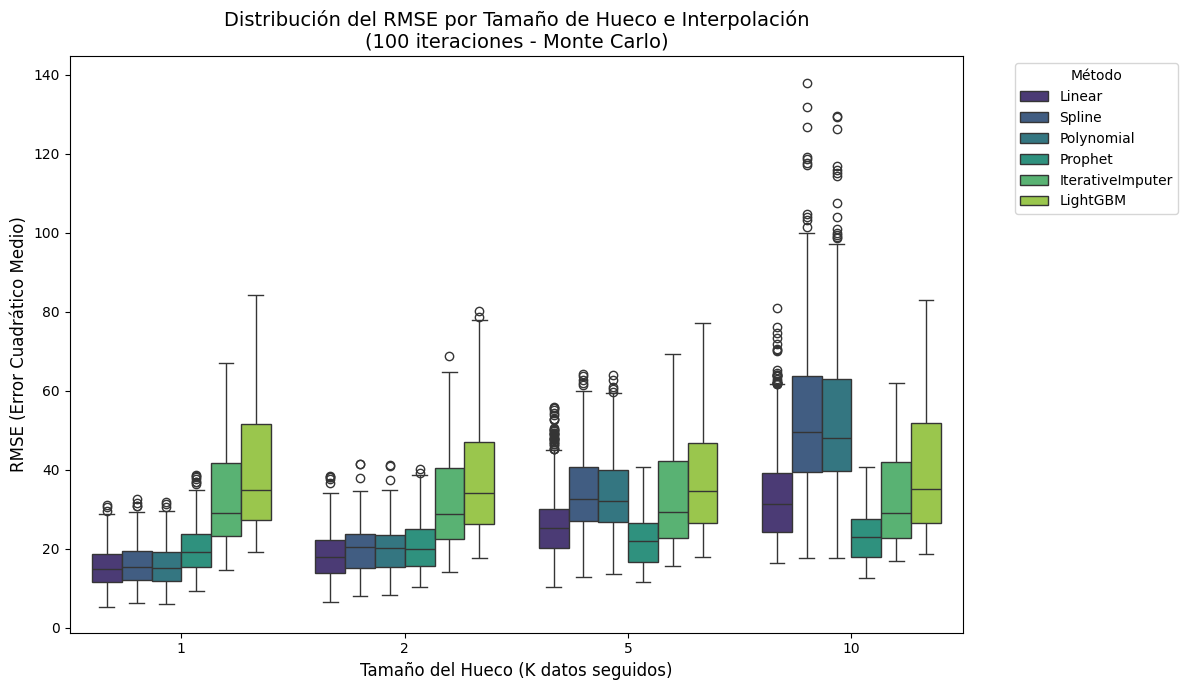

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración de estilo
#sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Generación del Boxplot
# Usamos df_benchmark porque contiene todas las iteraciones (no el df_final_stats)
ax = sns.boxplot(
    data=df_benchmark, 
    x='Size_K', 
    y='RMSE', 
    hue='Method',
    palette='viridis',
    showfliers=True
)

# Personalización de ejes y títulos
plt.title('Distribución del RMSE por Tamaño de Hueco e Interpolación\n(100 iteraciones - Monte Carlo)', fontsize=14)
plt.xlabel('Tamaño del Hueco (K datos seguidos)', fontsize=12)
plt.ylabel('RMSE (Error Cuadrático Medio)', fontsize=12)
plt.legend(title='Método', bbox_to_anchor=(1.05, 1), loc='upper left')


plt.tight_layout()
plt.show()

In [13]:
# Comparación global simple
ranking = (
    df_benchmark
    .groupby(['Method', 'Size_K'])['RMSE']
    .mean()
    .reset_index()
)

ranking['Rank'] = ranking.groupby('Size_K')['RMSE']\
                          .rank(method='average')

print(ranking.sort_values(['Size_K','Rank']))

              Method  Size_K       RMSE  Rank
8             Linear       1  15.439542   1.0
12        Polynomial       1  15.686926   2.0
20            Spline       1  16.016769   3.0
16           Prophet       1  20.341910   4.0
0   IterativeImputer       1  32.899571   5.0
4           LightGBM       1  41.338424   6.0
9             Linear       2  18.688573   1.0
13        Polynomial       2  20.113905   2.0
21            Spline       2  20.303608   3.0
17           Prophet       2  21.044315   4.0
1   IterativeImputer       2  32.594110   5.0
5           LightGBM       2  38.537354   6.0
18           Prophet       5  22.681381   1.0
10            Linear       5  27.482270   2.0
2   IterativeImputer       5  33.223734   3.0
14        Polynomial       5  34.152008   4.0
22            Spline       5  34.828749   5.0
6           LightGBM       5  38.185152   6.0
19           Prophet      10  23.777949   1.0
3   IterativeImputer      10  32.988721   2.0
11            Linear      10  34.9

In [14]:
# Ranking promedio global
ranking_global = (
    ranking
    .groupby('Method')['Rank']
    .mean()
    .reset_index()
    .sort_values('Rank')
)

print(ranking_global)


             Method  Rank
2            Linear  1.75
4           Prophet  2.50
3        Polynomial  3.25
0  IterativeImputer  3.75
5            Spline  4.25
1          LightGBM  5.50


In [15]:
# Considerar estabilidad
estabilidad = (
    df_benchmark
    .groupby(['Method', 'Size_K'])['RMSE']
    .std()
    .reset_index()
)

# score combinado penaliza métodos inestables
resumen = (
    df_benchmark
    .groupby(['Method', 'Size_K'])['RMSE']
    .agg(['mean','std'])
    .reset_index()
)

resumen['Score'] = resumen['mean'] + resumen['std']
resumen = resumen.sort_values(by=['Size_K', 'Score'], ascending=[True, True])

top_metodos = resumen.groupby('Size_K').head(3)

print("--- Ranking de Métodos por Tamaño de Hueco (K) ---")
print(top_metodos.to_string(index=False))


--- Ranking de Métodos por Tamaño de Hueco (K) ---
          Method  Size_K      mean       std     Score
          Linear       1 15.439542  5.069789 20.509331
      Polynomial       1 15.686926  5.251363 20.938290
          Spline       1 16.016769  5.386104 21.402873
          Linear       2 18.688573  6.274957 24.963529
      Polynomial       2 20.113905  6.213694 26.327599
          Spline       2 20.303608  6.311711 26.615319
         Prophet       5 22.681381  7.171928 29.853309
          Linear       5 27.482270 10.629797 38.112067
      Polynomial       5 34.152008 11.022745 45.174753
         Prophet      10 23.777949  7.067059 30.845009
IterativeImputer      10 32.988721 12.037870 45.026591
          Linear      10 34.983697 14.545091 49.528788


In [16]:
from scipy.stats import friedmanchisquare

# Crear matriz método x escenario
pivot = (
    df_benchmark
    .groupby(['Method','Series','Size_K'])['RMSE']
    .mean()
    .reset_index()
    .pivot_table(index=['Series','Size_K'],
                 columns='Method',
                 values='RMSE')
)

friedmanchisquare(*[pivot[col] for col in pivot.columns])# Si el p-valor < 0.05 existen diferencias significativas.

FriedmanchisquareResult(statistic=np.float64(94.85714285714278), pvalue=np.float64(6.399092741458015e-19))

Probar transferlearning. 